In [173]:
import pandas as pd
import matplotlib.pyplot as plt
#warnings

In [174]:
veri=pd.read_csv(r"C:\Users\USER\Downloads\38833FF26BA1D.UnigramPreview_g9c9v27vpyspw!App\personel.csv",delimiter=";")

In [175]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         191 non-null    float64
 1   Education   190 non-null    object 
 2   Salary      181 non-null    float64
 3   Department  0 non-null      float64
dtypes: float64(3), object(1)
memory usage: 6.4+ KB


In [176]:
#veri.drop("Department")

In [177]:
veri.head()

,Age,Education,Salary,Department
0,38.0,Lisans,36000.0,NaN
1,50.0,Doktora,NaN,NaN
2,24.0,Lisans,36000.0,NaN
3,60.0,Y.Lisans,52000.0,NaN
4,44.0,Lisans,28000.0,NaN


## 2. Department Sütununu Silme

In [178]:
veri.drop("Department",axis=1,inplace=True)
veri.head()

,Age,Education,Salary
0,38.0,Lisans,36000.0
1,50.0,Doktora,NaN
2,24.0,Lisans,36000.0
3,60.0,Y.Lisans,52000.0
4,44.0,Lisans,28000.0


## 2. Sütun İsimlerini Değiştirme

In [179]:
veri.rename(columns={"Age":"Yas","Education":"Egitim","Salary":"Maas"},inplace=True)
#veri.columns=['Yas','Egitim','Maas']


In [180]:
veri.head()

,Yas,Egitim,Maas
0,38.0,Lisans,36000.0
1,50.0,Doktora,NaN
2,24.0,Lisans,36000.0
3,60.0,Y.Lisans,52000.0
4,44.0,Lisans,28000.0


## 4. Eğitim Bilgisi Grilmemiş Stırları silme 

In [181]:
filtre=veri["Egitim"].notna()
veri=veri[filtre]

In [182]:
veri.info()
veri.head()

<class 'pandas.core.frame.DataFrame'>
Index: 190 entries, 0 to 199
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Yas     181 non-null    float64
 1   Egitim  190 non-null    object 
 2   Maas    177 non-null    float64
dtypes: float64(2), object(1)
memory usage: 5.9+ KB


,Yas,Egitim,Maas
0,38.0,Lisans,36000.0
1,50.0,Doktora,NaN
2,24.0,Lisans,36000.0
3,60.0,Y.Lisans,52000.0
4,44.0,Lisans,28000.0


## 5. Yaşı girilmemiş olanları ortalama yaş ile güncelle

In [160]:
ortalamaYas=int(veri["Yas"].mean())
veri.Yas.fillna(ortalamaYas,inplace=True)

In [161]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
Index: 190 entries, 0 to 199
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Yas     190 non-null    float64
 1   Egitim  190 non-null    object 
 2   Maas    177 non-null    float64
dtypes: float64(2), object(1)
memory usage: 5.9+ KB


## 6. Maaşı girilmemiş olanları eğitim seviyesine göre ortalama ile güncelleme

In [172]:
import numpy as np
veri_gecici=veri.copy()
benzersiz_egitim=veri["Egitim"].unique()    #["Y.Lisans","Lisans","Doktora"]
for e in benzersiz_egitim:
    egitim_filtre=veri_gecici.Egitim==e
    filtreli_veri=veri_gecici[egitim_filtre]
    ortalama=np.round(np.mean(filtreli_veri.Maas),2)
    filtreli_veri.Maas.fillna(ortalama,inplace=True)
    veri_gecici[egitim_filtre]=filtreli_veri

veri=veri_gecici.copy()
veri.info()
veri.head()

<class 'pandas.core.frame.DataFrame'>
Index: 190 entries, 0 to 199
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Yas     190 non-null    float64
 1   Egitim  190 non-null    object 
 2   Maas    190 non-null    float64
dtypes: float64(2), object(1)
memory usage: 5.9+ KB


C:\Users\USER\AppData\Local\Temp\ipykernel_3260\2147618477.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtreli_veri.Maas.fillna(ortalama,inplace=True)


,Yas,Egitim,Maas
0,38.0,Lisans,36000.00
1,50.0,Doktora,58166.67
2,24.0,Lisans,36000.00
3,60.0,Y.Lisans,52000.00
4,44.0,Lisans,28000.00


## 7. Yas Histogramı 

Text(0, 0.5, 'frekans')

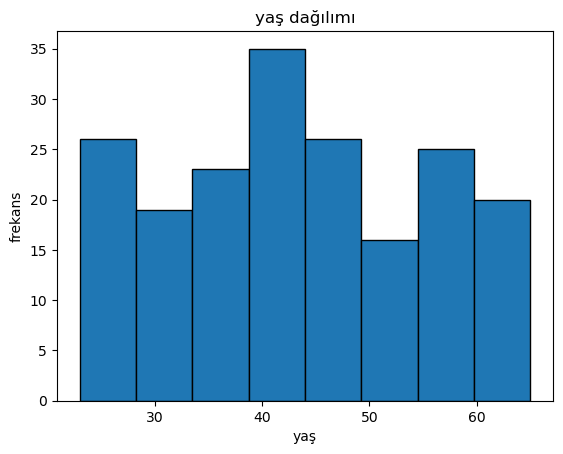

In [163]:
plt.figure()
plt.hist(veri["Yas"],bins=8,edgecolor="black")
plt.title("yaş dağılımı")
plt.xlabel("yaş")
plt.ylabel("frekans")

## 8. Eğitim seviyelerine göre ortalama maaş bar plot

In [164]:
benzersiz_egitim=veri["Egitim"].unique()
ortalama_maas=[]
for egitim in benzersiz_egitim:
    filtreli_veri=veri[veri["Egitim"]==egitim]["Maas"]
    ortalama_maas.append(filtreli_veri.mean())

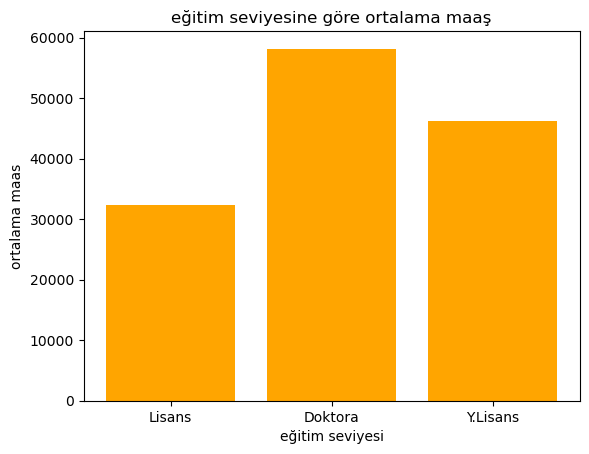

In [165]:
plt.figure()
plt.bar(benzersiz_egitim,ortalama_maas,color="orange")
plt.title("eğitim seviyesine göre ortalama maaş")
plt.xlabel("eğitim seviyesi")
plt.ylabel("ortalama maas")
plt.xticks(rotation=0)
plt.show()

## 9. Notlara göre azalan sırada sıralama

In [166]:
ogrenciler=[{"isim":"Ahmet","not":85},
            {"isim":"Mehmet","not":90},
            {"isim":"Ali","not":75},
            {"isim":"Ayşe","not":95}]

In [167]:
notlara_gore=sorted(ogrenciler,key=lambda x:{"not"},reverse=True)
notlara_gore

[{'isim': 'Ahmet', 'not': 85},
 {'isim': 'Mehmet', 'not': 90},
 {'isim': 'Ali', 'not': 75},
 {'isim': 'Ayşe', 'not': 95}]

## 10. İsim uzunluğuna göre artan sırada sıralama

In [168]:
isim_uzunluguna_gore=sorted(ogrenciler,key=lambda x: len(x["isim"]))
isim_uzunluguna_gore

[{'isim': 'Ali', 'not': 75},
 {'isim': 'Ayşe', 'not': 95},
 {'isim': 'Ahmet', 'not': 85},
 {'isim': 'Mehmet', 'not': 90}]